In [115]:
import pybamm
import numpy as np
import matplotlib.pyplot as plt

# # import  settings
# import plot_settings
# plot_settings.apply()

In [116]:
# load model
model = pybamm.lithium_ion.DFN()


# create geometry
geometry = model.default_geometry

# load parameter values and process model and geometry
param = model.default_parameter_values

# def my_fun(A):
#     def current(t):
#         return A * pybamm.sin(2 * np.pi * 0.1 * t)
#     return current

# # set user defined current function
# A = model.param.I_typ
# print("Amplitude [A]: ", A)
# param["Current function [A]"] = my_fun

param.process_geometry(geometry)
param.process_model(model)

# create simulation
simulation = pybamm.Simulation(model, parameter_values=param)

# set mesh
var = pybamm.standard_spatial_vars
var_pts = {var.x_n: 30, var.x_s: 30, var.x_p: 30, var.r_n: 10, var.r_p: 10}
mesh = pybamm.Mesh(geometry, model.default_submesh_types, var_pts)

# discretise model
disc = pybamm.Discretisation(mesh, model.default_spatial_methods)
disc.process_model(model);

In [117]:
# solve model
t_eval = [0, 3600]
solver = pybamm.IDAKLUSolver(atol=1e-6, rtol=1e-3)
solution = solver.solve(model, t_eval)

In [118]:
# # variables
# for k, v in zip(model.variables.keys(), model.variables.values()):
#     print(f"{k}\t\t{v}")

# model.print_parameter_info()
# print(param)

# for var, eq in model.rhs.items():
#     print(var, eq)

In [119]:
plot = pybamm.QuickPlot(solution,
                    output_variables=[
                        "Voltage [V]",
                        "Current [A]",
                    ],
                    time_unit="minutes")
plot.dynamic_plot()

interactive(children=(FloatSlider(value=0.0, description='t', max=60.0, step=0.6), Output()), _dom_classes=('w…

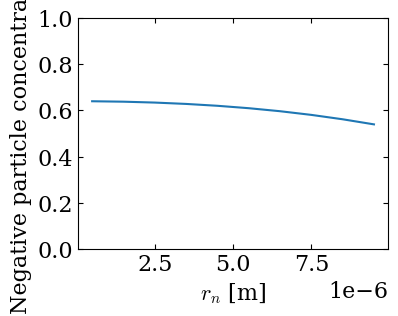

In [137]:
c_s_n = solution["Negative particle concentration"]
r_n = solution["r_n [m]"].entries[:, 0, 1]

t = solution["Time [s]"].entries
x = solution["x [m]"].entries[:, 0]

def plot_concentrations(t):
    fig, ax1 = plt.subplots(1, 1, figsize=(4, 3))
    
    # Evaluate concentration at specific time and x position (returns values at all r points)
    c_vals = c_s_n(r=r_n, t=t, x=x[0])
    
    ax1.plot(r_n, c_vals)
    ax1.set_ylabel("Negative particle concentration")
    ax1.set_xlabel(r"$r_n$ [m]")
    ax1.set_ylim(0, 1)

plot_concentrations(t=1600)  # plot at 1800 s

Text(0.5, 1.0, 'Negative particle concentration at t')

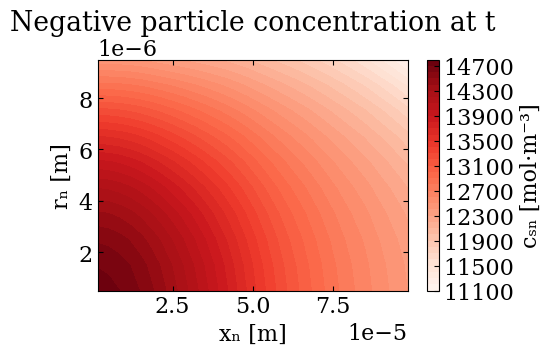

In [123]:
import matplotlib as mpl
mpl.rcParams["text.usetex"] = False

# Solution variables
c_s_n = solution["Negative particle concentration [mol.m-3]"]
r_n = solution["r_n [m]"].entries         # shape (nr, nx, nt)
x_n = solution["x_n [m]"].entries         # shape (nx, nt)
t_vals = solution["Time [s]"].entries     # shape (nt,)

# Choose a time index
t0 = 1800
# find nearest index in the time array
ti = np.argmin(np.abs(t_vals - t0))

# Extract r grid and x grid at that time
# r_n is (nr, nx, nt) so take r_n[..., ti]
r2d = r_n[..., ti]    # shape (nr, nx)
x2d = x_n[..., ti]    # shape (nx,)

# Concentration is (nr, nx, nt) as well
c2d = c_s_n.entries[..., ti]  # shape (nr, nx)

# Now plot
fig, ax = plt.subplots(figsize=(5, 3))
X, R = np.meshgrid(x2d, r2d[:, 0])  # r varies along rows, x along columns

cs = ax.contourf(X, R, c2d, levels=40, cmap="Reds")
fig.colorbar(cs, ax=ax, label="cₛₙ [mol·m⁻³]")

ax.set_xlabel("xₙ [m]")
ax.set_ylabel("rₙ [m]")
ax.set_title(f"Negative particle concentration at t")

Text(0.5, 1.0, 'Negative particle concentration at t')

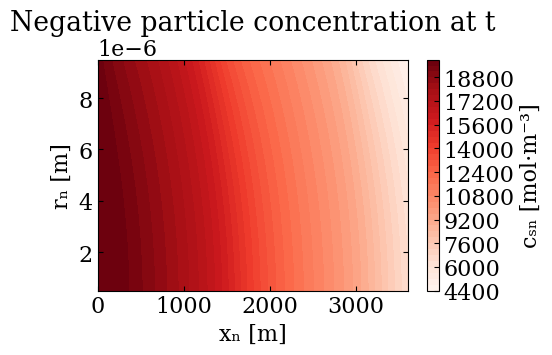

In [140]:
# Solution variables
c_s_n = solution["Negative particle concentration [mol.m-3]"]
r_n = solution["r_n [m]"].entries         # shape (nr, nx, nt)
x_n = solution["x_n [m]"].entries         # shape (nx, nt)
t_vals = solution["Time [s]"].entries     # shape (nt,)

# Choose a time index
t0 = 1800
# find nearest index in the time array
ti = np.argmin(np.abs(t_vals - t0))


# Extract r grid and x grid at that time
# r_n is (nr, nx, nt) so take r_n[..., ti]
x1 = 10
r2d = r_n[:, x1, :]    # shape (nr, nx)
# Concentration is (nr, nx, nt) as well
c2d = c_s_n.entries[:, x1, :]  # shape (nr, nx)

# Now plot
fig, ax = plt.subplots(figsize=(5, 3))
T, R = np.meshgrid(t_vals, r2d[:, 0])  # r varies along rows, x along columns
cs = ax.contourf(T, R, c2d, levels=40, cmap="Reds")
fig.colorbar(cs, ax=ax, label="cₛₙ [mol·m⁻³]")

ax.set_xlabel("xₙ [m]")
ax.set_ylabel("rₙ [m]")
ax.set_title(f"Negative particle concentration at t")